# 1. ToolNode替代手动工具调用

In [6]:
# 动态跳转 : Command [goto, update]
from typing import Literal

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from rich import print

load_dotenv(override=True)

model = init_chat_model(
    model_provider="deepseek",
    model="deepseek-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 定义工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """根据城市名称查询天气

    Args:
        city (str): 城市名称

    Returns:
        str: 城市天气情况
    """
    return f"{city} 的天气是晴天，温度 25°C"


@tool(parse_docstring=True)
def get_news(topic: Literal["科技", "体育", "娱乐"]) -> str:
    """根据主题查询新闻

    Args:
        topic (Literal["科技", "体育", "娱乐"]): 新闻主题

    Returns:
        str: 新闻内容
    """
    return {
        "科技": "最新科技新闻：AI 技术正在快速发展。",
        "体育": "最新体育新闻：中国队取得了胜利。",
        "娱乐": "最新娱乐新闻：歌手发布了新专辑。",
    }[topic]


tools = [get_weather, get_news]
model_with_tools = model.bind_tools(tools)


# 定义状态
class State(MessagesState):
    pass


# 工具节点
# ===== 手写 tool_node 的全部工作（映射表、遍历、invoke、ToolMessage）都由 ToolNode 完成 =====
tool_node = ToolNode(tools, handle_tool_errors=True)  # 异常自动转错误 ToolMessage 回给模型自纠


# 模型节点
def llm_node(state: State) -> State:
    ai_msg = model_with_tools.invoke(state["messages"])
    return {"messages": [ai_msg]}


def router(state: State) -> Literal["tool_node", END]:
    # 判断本轮模型输出：有 tool_calls 去工具节点，没有就结束
    return "tool_node" if state["messages"][-1].tool_calls else END


builder = StateGraph(state_schema=State)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, [END, "tool_node"])  # 动态跳转
builder.add_edge("tool_node", "llm_node")  # 固定回环

graph = builder.compile()
res = graph.invoke({"messages": [HumanMessage("帮我查一下北京的天气和科技相关的新闻")]})
print(res)

{
    'messages': [
        HumanMessage(
            content='帮我查一下北京的天气和科技相关的新闻',
            additional_kwargs={},
            response_metadata={},
            id='d92cc58f-32c3-427c-8e52-7913a7dbf948'
        ),
        AIMessage(
            content='我来帮您查询北京的天气和科技新闻。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 76,
                    'prompt_tokens': 345,
                    'total_tokens': 421,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 128,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 128,
                    'prompt_cache_miss_tokens': 217
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': 'ea941c34-6e6c-4bc2-b30e-efd687b478ea',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ab54-94ba-7030-abaa-f985a68e9b64-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_kgHefs70MTCXdSRUbUb81258',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'topic': '科技'},
                    'id': 'call_01_FpEXygy5EZO5c2yFWC086703',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 345,
                'output_tokens': 76,
                'total_tokens': 421,
                'input_token_details': {'cache_read': 128},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='北京 的天气是晴天，温度 25°C',
            name='get_weather',
            id='a72007cc-3443-4b81-b513-fa44e7743556',
            tool_call_id='call_00_kgHefs70MTCXdSRUbUb81258'
        ),
        ToolMessage(
            content='最新科技新闻：AI 技术正在快速发展。',
            name='get_news',
            id='bab43dbf-f1fd-4c39-a92b-1f93560ef405',
            tool_call_id='call_01_FpEXygy5EZO5c2yFWC086703'
        ),
        AIMessage(
            content='已经帮您查到了，以下是结果：\n\n**🌤️ 北京天气**\n- 天气：晴天\n- 温度：25°C\n\n**📰 
科技新闻**\n- 最新科技新闻：AI 技术正在快速发展。\n\n北京今天天气不错，晴天 
25°C，很适合外出活动。科技方面，目前最受关注的是 AI 
技术的快速发展。如果您想了解更具体的科技新闻内容（比如某个公司或细分领域），可以再告诉我～',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 98,
                    'prompt_tokens': 462,
                    'total_tokens': 560,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 256,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 206
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': 'fae60978-50c0-46dc-87b9-2eda81739a1d',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0ab54-96ee-72c3-8cef-5cb8f8934fc8-0',
            tool_calls=[],
            invalid_

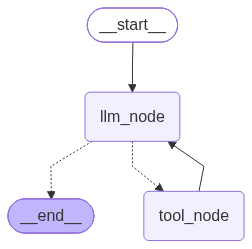

None

In [7]:
from IPython.display import display

print(display(graph))